<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/EDP-1/blob/main/LineasDEspera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q =\begin{pmatrix}
-2 & 2 & 0\\
3 & -4 & 1\\
1/2 & 0  & -1/2
\end{pmatrix}


$P(t)=e^{tQ}$



Modelo: $S={0,1,2}$
* Estado 0: Servidor libre
* Estado 1: Servidor ocupado
* Estado 2: Servidor caido

1.- Calcular $P(t)$ en sympy
  Responder:
1.   Si el sistema inicia libre, ¿Cuál es la probabilidad de estar caido despues de $t=1$?
2.   ¿Cómo cambia $P(t)$ cuando $t\rightarrow \infty$ ?
3.    Graficar
*  $P_{00}(t)$
*  $P_{01}(t)$
*  $P_{02}(t)$
4. Simular algunas trayectorias y comparar con los resultados analiticos.

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Construimos la matriz de Q usando la libreria Sympy

Q = sp.Matrix([[-2,   2,   0],
               [3, -4, 1],
               [  1/2,   0, -1/2]])
# Mostrar matriz
Q

Matrix([
[ -2,  2,    0],
[  3, -4,    1],
[0.5,  0, -0.5]])

$P(t)=e^{tQ}$

In [20]:

P_t = sp.exp(t*Q)
P_t

Matrix([
[ 0.4 + 0.310599978800064*exp(-5.60849528301415*t) + 0.289400021199936*exp(-0.891504716985849*t),  0.2 - 0.386199427601717*exp(-5.60849528301415*t) + 0.186199427601717*exp(-0.891504716985849*t),  0.4 + 0.0755994488016536*exp(-5.60849528301415*t) - 0.475599448801654*exp(-0.891504716985849*t)],
[ 0.4 - 0.560399279202162*exp(-5.60849528301415*t) + 0.160399279202162*exp(-0.891504716985849*t),  0.2 + 0.696799406401781*exp(-5.60849528301415*t) + 0.103200593598219*exp(-0.891504716985849*t),   0.4 - 0.136400127199618*exp(-5.60849528301415*t) - 0.263599872800382*exp(-0.891504716985849*t)],
[0.4 - 0.0304003391989824*exp(-5.60849528301415*t) - 0.369599660801018*exp(-0.891504716985849*t), 0.2 + 0.0377997244008268*exp(-5.60849528301415*t) - 0.237799724400827*exp(-0.891504716985849*t), 0.4 - 0.00739938520184439*exp(-5.60849528301415*t) + 0.607399385201844*exp(-0.891504716985849*t)]])


Modelo: $S={0,1,2}$
* Estado 0: Servidor libre
* Estado 1: Servidor ocupado
* Estado 2: Servidor caido

In [18]:
S={0,1,2}


1.- Calcular $P(t)$ en sympy

In [19]:
t = sp.Symbol('t')
P_t = sp.exp(t*Q)
P_t

Matrix([
[ 0.4 + 0.310599978800064*exp(-5.60849528301415*t) + 0.289400021199936*exp(-0.891504716985849*t),  0.2 - 0.386199427601717*exp(-5.60849528301415*t) + 0.186199427601717*exp(-0.891504716985849*t),  0.4 + 0.0755994488016536*exp(-5.60849528301415*t) - 0.475599448801654*exp(-0.891504716985849*t)],
[ 0.4 - 0.560399279202162*exp(-5.60849528301415*t) + 0.160399279202162*exp(-0.891504716985849*t),  0.2 + 0.696799406401781*exp(-5.60849528301415*t) + 0.103200593598219*exp(-0.891504716985849*t),   0.4 - 0.136400127199618*exp(-5.60849528301415*t) - 0.263599872800382*exp(-0.891504716985849*t)],
[0.4 - 0.0304003391989824*exp(-5.60849528301415*t) - 0.369599660801018*exp(-0.891504716985849*t), 0.2 + 0.0377997244008268*exp(-5.60849528301415*t) - 0.237799724400827*exp(-0.891504716985849*t), 0.4 - 0.00739938520184439*exp(-5.60849528301415*t) + 0.607399385201844*exp(-0.891504716985849*t)]])

1.   Si el sistema inicia libre, ¿Cuál es la probabilidad de estar caido despues de $t=1$?

In [29]:
P_at_1 = P_t.subs(t,1)
P_at_1

Matrix([
[0.519803932175414, 0.274932864130501, 0.205263203694086],
[0.463715097119272, 0.244871068044913, 0.291413834835815],
[ 0.24833851926495, 0.102631601847043, 0.649029878888007]])

In [21]:
# Extraer el elemento P_02(t) de la matriz P_t
P02_t = P_t[0, 2]

# Sustituir t=1 en la expresión
P02_at_1 = P02_t.subs(t, 1)

# Evaluar el resultado numéricamente
P02_numeric = P02_at_1.evalf()

print(f"La probabilidad P_02(1) es: {P02_numeric}")

La probabilidad P_02(1) es: 0.205263203694086



2. ¿Cómo cambia $P(t)$ cuando $t\rightarrow \infty$ ?

In [23]:
# Calcular el límite de P_t cuando t tiende a infinito element-wise
steady_state_matrix = P_t.applyfunc(lambda x: sp.limit(x, t, sp.oo))

print("Matriz de probabilidad en estado estacionario (t -> infinity):")
steady_state_matrix

Matriz de probabilidad en estado estacionario (t -> infinity):


Matrix([
[2/5, 1/5, 2/5],
[2/5, 1/5, 2/5],
[2/5, 1/5, 2/5]])

3.    Graficar
*  $P_{00}(t)$
*  $P_{01}(t)$
*  $P_{02}(t)$

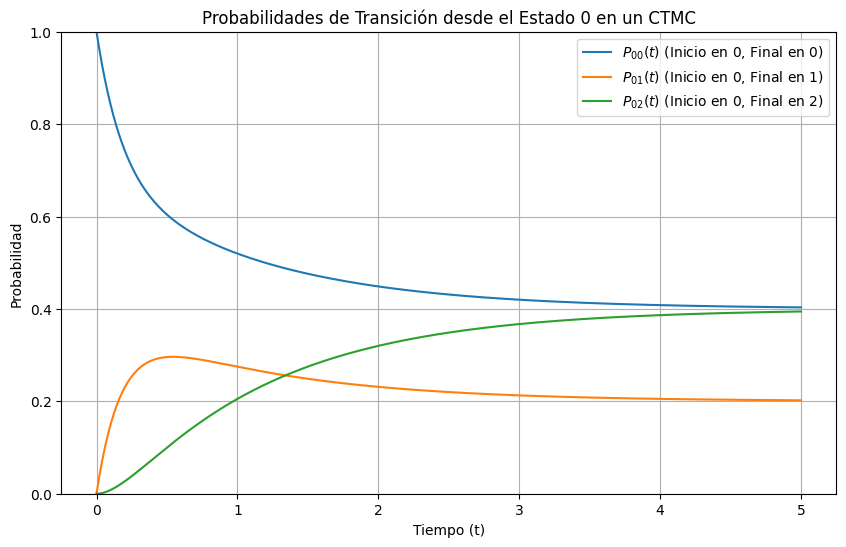

In [24]:
# Extraer las expresiones simbólicas para P_00(t), P_01(t) y P_02(t)
P00_t = P_t[0, 0]
P01_t = P_t[0, 1]
P02_t = P_t[0, 2]

# Convertir las expresiones simbólicas en funciones numéricas
f_P00 = sp.lambdify(t, P00_t, 'numpy')
f_P01 = sp.lambdify(t, P01_t, 'numpy')
f_P02 = sp.lambdify(t, P02_t, 'numpy')

# Definir un rango de valores para t (por ejemplo, de 0 a 5)
t_values = np.linspace(0, 5, 500)

# Calcular los valores de las probabilidades para cada t
values_P00 = f_P00(t_values)
values_P01 = f_P01(t_values)
values_P02 = f_P02(t_values)

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(t_values, values_P00, label='$P_{00}(t)$ (Inicio en 0, Final en 0)')
plt.plot(t_values, values_P01, label='$P_{01}(t)$ (Inicio en 0, Final en 1)')
plt.plot(t_values, values_P02, label='$P_{02}(t)$ (Inicio en 0, Final en 2)')

plt.title('Probabilidades de Transición desde el Estado 0 en un CTMC')
plt.xlabel('Tiempo (t)')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(True)
plt.ylim(0, 1) # Las probabilidades deben estar entre 0 y 1
plt.show()

4. Simular algunas trayectorias y comparar con los resultados analiticos.

In [26]:
import random

def simulate_ctmc(Q_matrix, initial_state, time_horizon, states):
    """
    Simulates a single trajectory of a Continuous-Time Markov Chain.

    Args:
        Q_matrix (sp.Matrix): The generator matrix Q.
        initial_state (int): The starting state of the simulation.
        time_horizon (float): The total time to simulate.
        states (list): A list of possible states (e.g., [0, 1, 2]).

    Returns:
        list: A list of (time, state) tuples representing the trajectory.
    """
    current_time = 0.0
    current_state = initial_state
    trajectory = [(current_time, current_state)]

    while current_time < time_horizon:
        # Get transition rates from current state
        rates_from_current_state = [Q_matrix[current_state, j] for j in states]

        # Calculate the total exit rate (lambda_i = -Q_ii)
        lambda_i = -Q_matrix[current_state, current_state]

        if lambda_i == 0: # If it's an absorbing state
            trajectory.append((time_horizon, current_state))
            break

        # Calculate holding time in current_state (exponential distribution)
        holding_time = random.expovariate(lambda_i)

        # Determine next transition time
        next_time = current_time + holding_time

        # If next transition goes beyond time_horizon, clip it
        if next_time > time_horizon:
            trajectory.append((time_horizon, current_state))
            break

        # Calculate transition probabilities to other states
        # P(i -> j) = Q_ij / lambda_i for j != i
        transition_probabilities = []
        for j in states:
            if j != current_state:
                # Avoid numerical issues with sympy floats
                prob = float(Q_matrix[current_state, j] / lambda_i)
                transition_probabilities.append(max(0.0, prob)) # Ensure non-negative
            else:
                transition_probabilities.append(0.0) # Cannot transition to self this way

        # Normalize probabilities to account for potential small numerical errors
        total_prob = sum(transition_probabilities)
        if total_prob > 0:
            transition_probabilities = [p / total_prob for p in transition_probabilities]
        else:
            # If no outgoing transitions, it's an absorbing state or error
            trajectory.append((time_horizon, current_state))
            break

        # Choose next state based on transition probabilities
        next_state = random.choices(states, weights=transition_probabilities, k=1)[0]

        current_time = next_time
        current_state = next_state
        trajectory.append((current_time, current_state))

    return trajectory

Now, let's run a single simulation to see how a trajectory looks.

In [27]:
# Example usage of the simulation function
initial_state_sim = 0
time_horizon_sim = 10.0
possible_states = list(S) # Ensure S is defined, assuming it's {0,1,2}

# Ensure Q is a numeric matrix for simulation, not symbolic
Q_numeric = np.array(Q).astype(float)

single_trajectory = simulate_ctmc(Q, initial_state_sim, time_horizon_sim, possible_states)

print("Single simulated trajectory (time, state):")
for time_val, state_val in single_trajectory:
    print(f"  Time: {time_val:.2f}, State: {state_val}")

Single simulated trajectory (time, state):
  Time: 0.00, State: 0
  Time: 0.55, State: 1
  Time: 1.01, State: 0
  Time: 1.13, State: 1
  Time: 1.18, State: 0
  Time: 2.87, State: 1
  Time: 3.22, State: 0
  Time: 3.52, State: 1
  Time: 3.68, State: 0
  Time: 3.81, State: 1
  Time: 4.01, State: 2
  Time: 5.59, State: 0
  Time: 5.89, State: 1
  Time: 5.96, State: 0
  Time: 6.51, State: 1
  Time: 7.13, State: 0
  Time: 7.19, State: 1
  Time: 7.49, State: 2
  Time: 7.63, State: 0
  Time: 8.42, State: 1
  Time: 8.48, State: 2
  Time: 8.72, State: 0
  Time: 9.19, State: 1
  Time: 9.28, State: 0
  Time: 9.53, State: 1
  Time: 9.66, State: 0
  Time: 10.00, State: 0


Now, let's run multiple simulations to gather data for comparison with analytical results. We'll simulate 1000 trajectories and calculate the proportion of time spent in each state.

In [ ]:
# Run multiple simulations
num_simulations = 1000
all_trajectories = []

for _ in range(num_simulations):
    all_trajectories.append(simulate_ctmc(Q, initial_state_sim, time_horizon_sim, possible_states))

print(f"Generated {num_simulations} trajectories.")

Next, we'll process these trajectories to estimate the proportion of time spent in each state. This will allow us to compare with the steady-state probabilities.

In [ ]:
def calculate_state_occupancy(trajectory, states, time_horizon):
    """
    Calculates the proportion of time spent in each state for a single trajectory.
    """
    state_times = {state: 0.0 for state in states}

    for i in range(len(trajectory) - 1):
        start_time, current_state = trajectory[i]
        end_time, _ = trajectory[i+1]
        time_in_state = end_time - start_time
        state_times[current_state] += time_in_state

    # Add time for the last state until time_horizon
    if len(trajectory) > 0:
        last_state_time, last_state = trajectory[-1]
        if last_state_time < time_horizon:
            state_times[last_state] += (time_horizon - last_state_time)

    # Normalize to get proportions
    total_sim_time = sum(state_times.values())
    if total_sim_time == 0: # Handle edge case of empty trajectory or 0 time horizon
        return {state: 0.0 for state in states}

    proportions = {state: time / total_sim_time for state, time in state_times.items()}
    return proportions

# Calculate average state occupancy across all simulations
agg_proportions = {state: 0.0 for state in possible_states}

for traj in all_trajectories:
    proportions = calculate_state_occupancy(traj, possible_states, time_horizon_sim)
    for state, prop in proportions.items():
        agg_proportions[state] += prop

# Average the proportions
for state in agg_proportions:
    agg_proportions[state] /= num_simulations

print("Average simulated state occupancy proportions:")
for state, prop in agg_proportions.items():
    print(f"  State {state}: {prop:.4f}")

Empezando a resolver analiticamente
